# 41 — EDA dos resultados parciais

Visualizacao consolidada dos `result_card.json` e `predictions.csv` em `artifacts/runs/`. Inclui:

- Inventario de runs (binario/multiclasse, regimes `fixed_split`, `cv_5fold`, `test_set`).
- Comparativos de F1 (binario) e macro-F1 (multiclasse), com desvios da CV 5-fold quando disponiveis.
- Heatmap de F1 per-class no esquema 7+other.
- Custo x qualidade (F1 vs tempo de inferencia, tamanho do modelo).
- Curvas ROC e Precision-Recall sobrepostas (binario, modelos com `y_score` no test_set).
- Matrizes de confusao (binaria e multiclasse) do melhor modelo BERT.
- Distribuicao real x predita das classes no test_set.
- Concordancia (Cohen's Kappa) pareada entre modelos binarios.
- Comparativo LLMs zero-shot x few-shot + cobertura de respostas.

Inclui tambem (no final) a **tabela consolidada do artigo** e o **McNemar pareado com Bonferroni** — escopo originalmente reservado a um notebook 42 separado, integrado aqui para evitar duplicacao com os comparativos e o heatmap de Cohen's Kappa que ja vivem nesta EDA.

## 0. Bootstrap (Colab + local)

Detecta o ambiente, monta o Drive em Colab, clona o repo e instala o pacote, e seleciona `RUNS_DIR` / `FIG_DIR` apropriados.

- **Colab**: le `result_card.json` e `predictions.csv` direto de `My Drive/economy-classifier/runs/` (onde 21_bert e 31_llm_hf escrevem). Figuras saem em `My Drive/economy-classifier/figures/eda/`.
- **Local**: usa `artifacts/runs/` e `artifacts/figures/eda/` do repo.

In [1]:
import subprocess
import sys
from pathlib import Path


def _run(cmd: list[str], description: str) -> None:
    print(f"$ {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr, file=sys.stderr)
        raise RuntimeError(f"{description} failed with exit code {result.returncode}")


IN_COLAB = "google.colab" in sys.modules
print("Ambiente:", "Google Colab" if IN_COLAB else "Local")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_URL = "https://github.com/almeidadm/economy-classifier.git"
    REPO_BRANCH = "main"
    DRIVE_FOLDER = "economy-classifier"

    DRIVE_BASE = Path("/content/drive/MyDrive") / DRIVE_FOLDER
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    REPO_DIR = Path("/content/economy-classifier")

    if REPO_DIR.exists():
        _run(["git", "-C", str(REPO_DIR), "fetch", "origin", REPO_BRANCH], "git fetch")
        _run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], "git checkout")
        _run(["git", "-C", str(REPO_DIR), "reset", "--hard", f"origin/{REPO_BRANCH}"], "git reset")
    else:
        _run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], "git clone")

    _run(
        [sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR),
         "--upgrade-strategy", "only-if-needed", "-q"],
        "pip install -e .",
    )
    if str(REPO_DIR / "src") not in sys.path:
        sys.path.insert(0, str(REPO_DIR / "src"))

    RUNS_DIR = DRIVE_BASE / "runs"
    FIG_DIR = DRIVE_BASE / "figures" / "eda"
else:
    REPO_DIR = Path.cwd().parent
    RUNS_DIR = REPO_DIR / "artifacts" / "runs"
    FIG_DIR = REPO_DIR / "artifacts" / "figures" / "eda"

assert RUNS_DIR.exists(), (
    f"RUNS_DIR nao encontrado: {RUNS_DIR}. "
    "No Colab, verifique que 21_bert/31_llm_hf rodaram e gravaram em "
    "My Drive/economy-classifier/runs/. Local: rode os notebooks 11-31 "
    "ou desempacote com scripts/colab_unpack_streaming.py."
)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("RUNS_DIR:", RUNS_DIR)
print("FIG_DIR :", FIG_DIR)

Ambiente: Local
RUNS_DIR: /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/runs
FIG_DIR : /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/figures/eda


## 1. Imports e configuracao

In [2]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from economy_classifier.visualization import configure_style

configure_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# RUNS_DIR e FIG_DIR vem do bootstrap acima.
print("RUNS_DIR:", RUNS_DIR)
print("FIG_DIR :", FIG_DIR)

RUNS_DIR: /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/runs
FIG_DIR : /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/figures/eda


In [3]:
# Helpers de carregamento
MULTICLASS_LABELS = [
    "poder", "colunas", "mercado", "esporte",
    "mundo", "cotidiano", "ilustrada", "outros",
]

FAMILY_BY_PREFIX = {
    "tfidf_": "TF-IDF",
    "bert_": "BERT",
    "llm_": "LLM",
}

def family_of(model_id: str) -> str:
    for prefix, fam in FAMILY_BY_PREFIX.items():
        if model_id.startswith(prefix):
            return fam
    return "other"

def load_cards(runs_dir: Path) -> list[dict]:
    cards = []
    for run_dir in sorted(runs_dir.iterdir()):
        card_path = run_dir / "result_card.json"
        if not card_path.is_file():
            continue
        with card_path.open() as f:
            card = json.load(f)
        card["_run_dir"] = str(run_dir)
        card["_run_name"] = run_dir.name
        card["_predictions_local"] = str(run_dir / "predictions.csv") if (run_dir / "predictions.csv").is_file() else None
        cards.append(card)
    return cards

cards = load_cards(RUNS_DIR)
print(f"{len(cards)} cards carregados")

27 cards carregados


## 1. Inventario de runs

Cards listados por `(model_id, task, regime)`. Cobertura indica se `predictions.csv` esta presente para a run. Note que algumas pastas com sufixo `*_test_set` contem na verdade um card de regime `cv_5fold` — o regime que vale e o do JSON, nao o do nome da pasta.

In [4]:
rows = []
for c in cards:
    metrics = c.get("metrics", {}) or {}
    cost = c.get("cost", {}) or {}
    rows.append({
        "run_name": c["_run_name"],
        "model_id": c.get("model_id"),
        "family": family_of(c.get("model_id", "")),
        "task": c.get("task"),
        "regime": c.get("regime"),
        "strategy": cost.get("strategy"),
        "f1": metrics.get("f1", metrics.get("f1_mean")),
        "f1_std": metrics.get("f1_std"),
        "macro_f1": metrics.get("macro_f1", metrics.get("macro_f1_mean")),
        "weighted_f1": metrics.get("weighted_f1", metrics.get("weighted_f1_mean")),
        "accuracy": metrics.get("accuracy", metrics.get("accuracy_mean")),
        "auc_roc": metrics.get("auc_roc", metrics.get("auc_roc_mean")),
        "coverage": metrics.get("coverage"),
        "n_eval": c.get("n_eval_samples"),
        "infer_s": cost.get("inference_seconds_mean", cost.get("inference_seconds")),
        "throughput": cost.get("throughput_samples_per_second"),
        "size_mb": cost.get("model_size_mb"),
        "hardware": cost.get("hardware"),
        "has_predictions": c["_predictions_local"] is not None,
    })

cards_df = pd.DataFrame(rows)
print("runs por (task, regime):")
print(cards_df.groupby(["task", "regime"]).size())
cards_df

runs por (task, regime):
task        regime     
binary      cv_5fold       4
            fixed_split    3
            test_set       8
multiclass  cv_5fold       2
            fixed_split    2
            test_set       8
dtype: int64


,run_name,model_id,family,task,regime,strategy,f1,f1_std,macro_f1,weighted_f1,accuracy,auc_roc,coverage,n_eval,infer_s,throughput,size_mb,hardware,has_predictions
0,bert_bertimbau_binary_cv_5fold,bert_bertimbau,BERT,binary,cv_5fold,NaN,0.8673,0.0028,NaN,NaN,0.9666,0.9873,NaN,149659,210.3112,142.32,436.407,Colab-L4,True
1,bert_bertimbau_binary_fixed_split,bert_bertimbau,BERT,binary,fixed_split,NaN,0.8700,NaN,NaN,NaN,0.9673,0.9881,NaN,16629,117.4656,141.56,436.407,Colab-L4,True
2,bert_bertimbau_binary_test_set,bert_bertimbau,BERT,binary,test_set,NaN,0.8675,NaN,NaN,NaN,0.9661,0.9876,NaN,16629,116.4242,142.83,436.407,Colab-L4,True
3,bert_bertimbau_multiclass_cv_5fold,bert_bertimbau,BERT,multiclass,cv_5fold,NaN,NaN,NaN,0.8863,0.8811,0.8814,NaN,NaN,149659,27.3580,1094.05,436.426,Colab-L4,True
4,bert_bertimbau_multiclass_fixed_split,bert_bertimbau,BERT,multiclass,fixed_split,NaN,NaN,NaN,0.8927,0.8877,0.8880,NaN,NaN,16629,14.6300,1136.64,436.426,Colab-L4,True
5,bert_bertimbau_multiclass_test_set,bert_bertimbau,BERT,multiclass,test_set,NaN,NaN,NaN,0.8941,0.8896,0.8899,NaN,NaN,16629,14.6200,1137.41,436.426,Colab-L4,True
6,bert_finbert_ptbr_binary_cv_5fold,bert_finbert_ptbr,BERT,binary,cv_5fold,NaN,0.8627,0.0042,NaN,NaN,0.9651,0.9858,NaN,149659,209.6664,142.76,436.407,Colab-L4,True
7,bert_finbert_ptbr_binary_fixed_split,bert_finbert_ptbr,BERT,binary,fixed_split,NaN,0.8633,NaN,NaN,NaN,0.9654,0.9883,NaN,16629,116.9517,142.19,436.407,Colab-L4,True
8,llm_llama_3_1_8b_instruct_binary_few_shot_test...,llm_llama_3_1_8b_instruct,LLM,binary,test_set,few_shot,0.7368,NaN,NaN,NaN,0.9259,0.8821,0.6784,199,196.9593,1.01,16060.500,Colab-L4,True
9,llm_llama_3_1_8b_instruct_binary_zero_shot_tes...,llm_llama_3_1_8b_instruct,LLM,binary,test_set,zero_shot,0.7458,NaN,NaN,NaN,0.9102,0.8977,0.8392,199,158.6437,1.25,16060.500,Colab-L4,True


## 2. Comparativo binario — CV 5-fold

F1 medio +- desvio padrao da CV 5-fold sobre o pool train+val (90%). LLMs nao tem regime CV (nao sao treinados); aparecem nos paineis subsequentes (`test_set`).

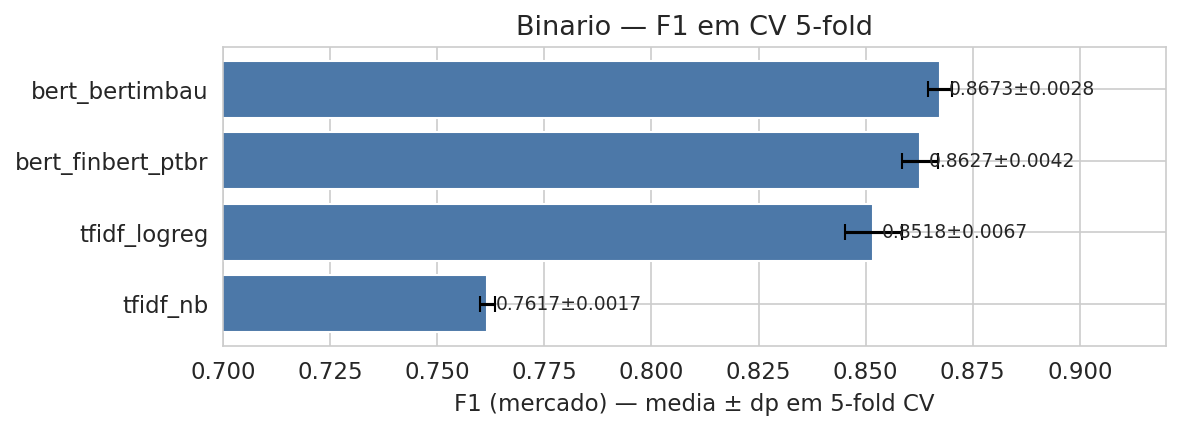

In [5]:
binary_cv = cards_df[(cards_df["task"] == "binary") & (cards_df["regime"] == "cv_5fold")].copy()
binary_cv = binary_cv.sort_values("f1", ascending=True)
binary_cv["label"] = binary_cv["model_id"]

fig, ax = plt.subplots(figsize=(8, max(3, 0.55 * len(binary_cv))))
y = np.arange(len(binary_cv))
ax.barh(y, binary_cv["f1"], xerr=binary_cv["f1_std"].fillna(0), color="#4C78A8", capsize=4)
for i, (f1, std) in enumerate(zip(binary_cv["f1"], binary_cv["f1_std"].fillna(0))):
    ax.text(f1 + 0.002, i, f"{f1:.4f}\u00b1{std:.4f}", va="center", fontsize=9)
ax.set_yticks(y, binary_cv["label"])
ax.set_xlabel("F1 (mercado) — media \u00b1 dp em 5-fold CV")
ax.set_title("Binario — F1 em CV 5-fold")
ax.set_xlim(0.7, 0.92)
fig.tight_layout()
fig.savefig(FIG_DIR / "binary_cv_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Comparativo binario — Test set (10%)

Numero unico do split fixo de 10%, refit em train+val. Inclui LLMs (avaliados em uma amostra reduzida — `n_eval` < 200, com cobertura abaixo de 100%).

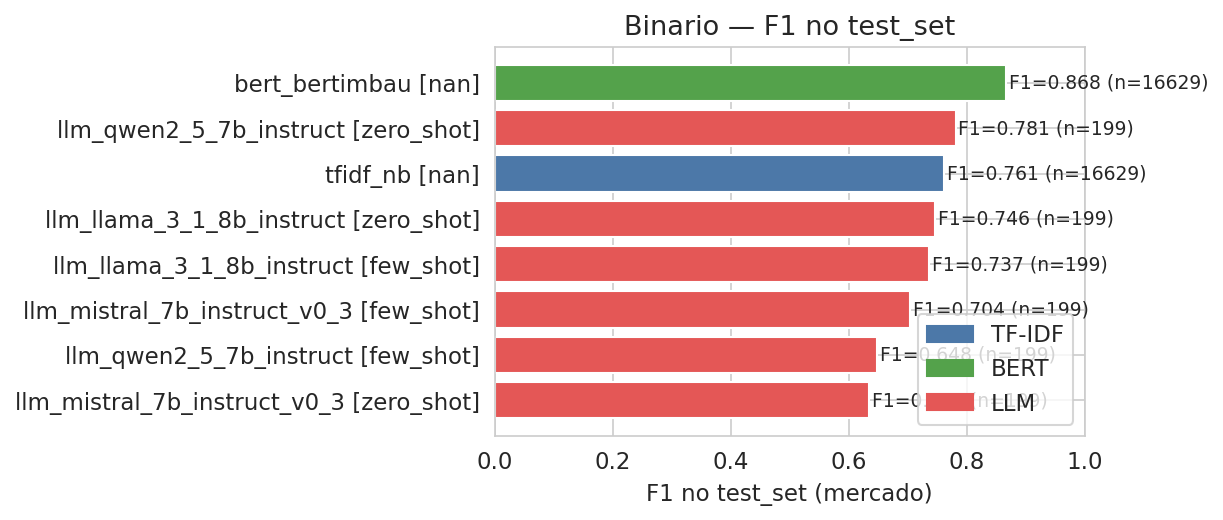

In [6]:
binary_test = cards_df[(cards_df["task"] == "binary") & (cards_df["regime"] == "test_set")].copy()
binary_test = binary_test.sort_values("f1", ascending=True)

def label_row(r):
    s = r["model_id"]
    if r["strategy"]:
        s = f"{s} [{r['strategy']}]"
    return s

binary_test["label"] = binary_test.apply(label_row, axis=1)

palette = {"TF-IDF": "#4C78A8", "BERT": "#54A24B", "LLM": "#E45756"}
colors = binary_test["family"].map(palette).fillna("#888")

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(binary_test))))
y = np.arange(len(binary_test))
ax.barh(y, binary_test["f1"], color=colors)
for i, (f1, n) in enumerate(zip(binary_test["f1"], binary_test["n_eval"])):
    ax.text(f1 + 0.005, i, f"F1={f1:.3f} (n={int(n)})", va="center", fontsize=9)
ax.set_yticks(y, binary_test["label"])
ax.set_xlabel("F1 no test_set (mercado)")
ax.set_xlim(0, 1.0)
ax.set_title("Binario — F1 no test_set")
handles = [plt.Rectangle((0,0),1,1, color=v) for v in palette.values()]
ax.legend(handles, palette.keys(), loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "binary_test_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Comparativo multiclasse (7+other) — Test set

Macro-F1 e weighted-F1 por modelo. LLMs avaliados em amostra reduzida do test_set.

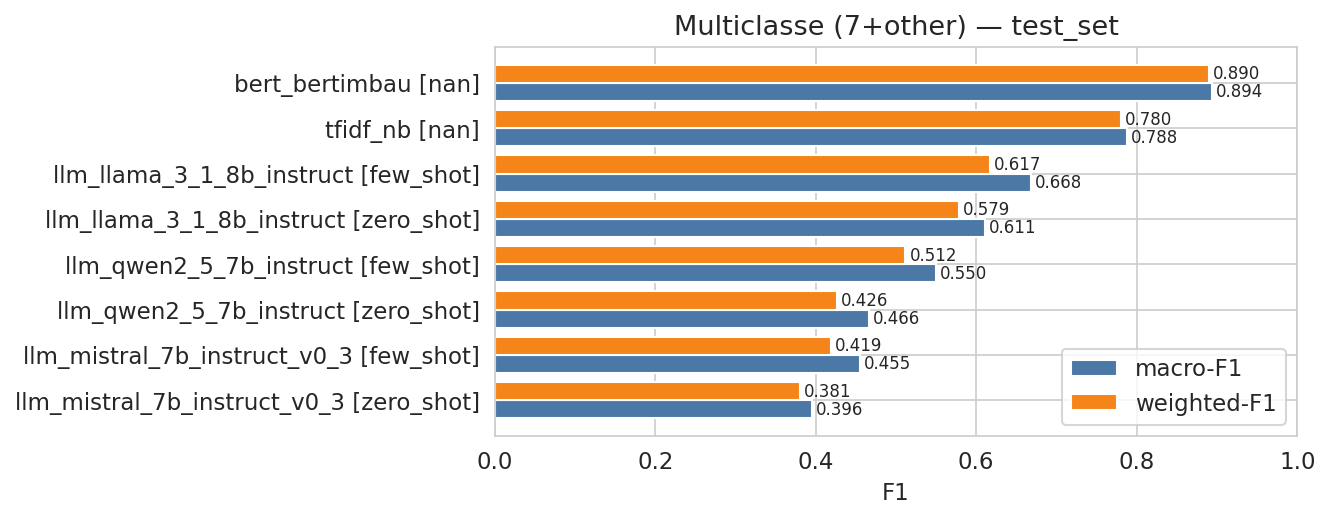

In [7]:
multi_test = cards_df[(cards_df["task"] == "multiclass") & (cards_df["regime"] == "test_set")].copy()
multi_test = multi_test.sort_values("macro_f1", ascending=True)
multi_test["label"] = multi_test.apply(label_row, axis=1)

fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(multi_test))))
y = np.arange(len(multi_test))
width = 0.4
ax.barh(y - width/2, multi_test["macro_f1"], height=width, color="#4C78A8", label="macro-F1")
ax.barh(y + width/2, multi_test["weighted_f1"], height=width, color="#F58518", label="weighted-F1")
for i, (mf, wf) in enumerate(zip(multi_test["macro_f1"], multi_test["weighted_f1"])):
    ax.text(mf + 0.005, i - width/2, f"{mf:.3f}", va="center", fontsize=8)
    ax.text(wf + 0.005, i + width/2, f"{wf:.3f}", va="center", fontsize=8)
ax.set_yticks(y, multi_test["label"])
ax.set_xlabel("F1")
ax.set_xlim(0, 1.0)
ax.set_title("Multiclasse (7+other) — test_set")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "multi_test_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. F1 per-class (multiclasse)

Heatmap modelo x classe. Mostra a heterogeneidade da rotulagem: `colunas` colapsa em LLMs (categoria editorialmente diversa), enquanto `esporte` e quase saturada em todos os modelos treinados.

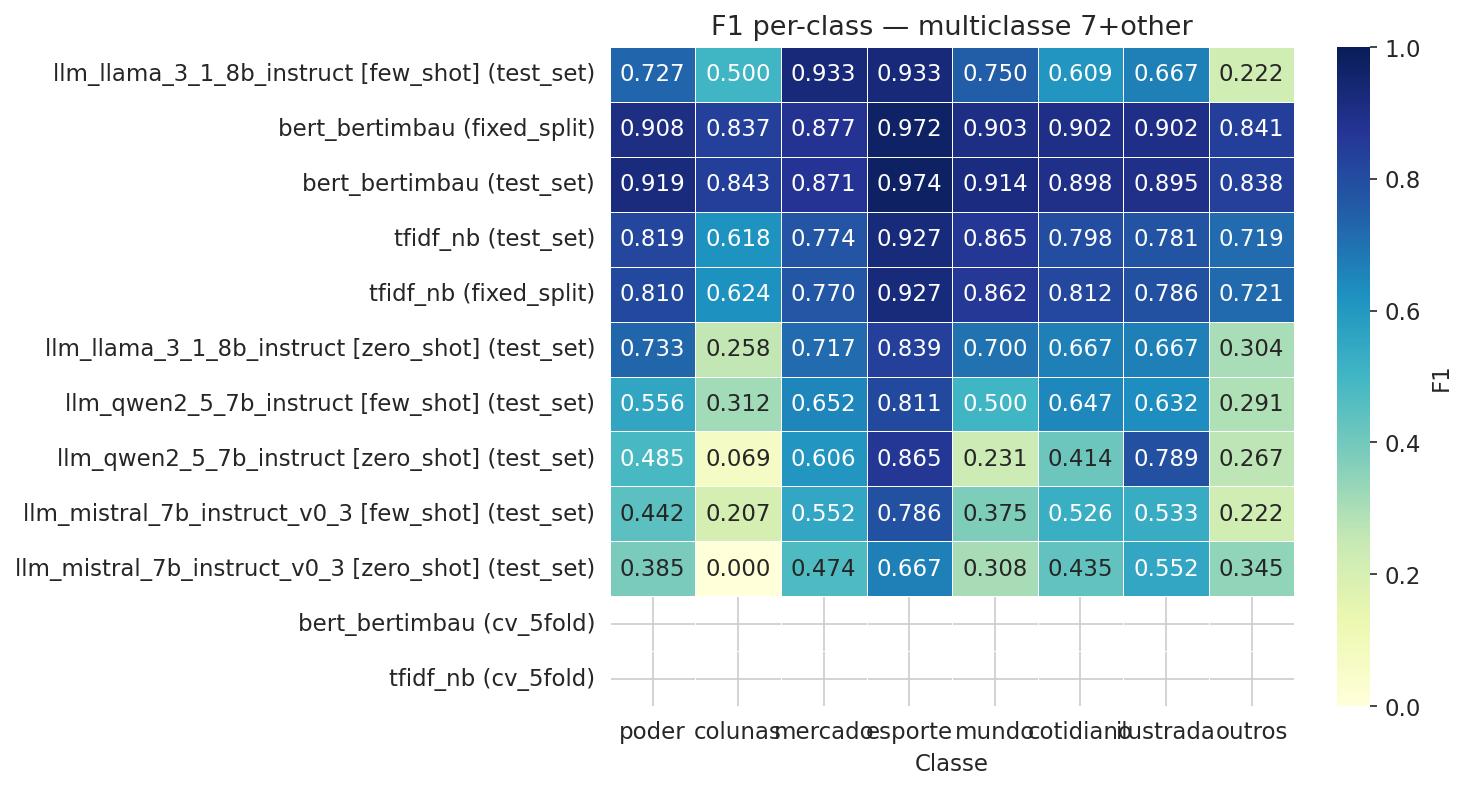

In [8]:
per_class_rows = []
for c in cards:
    if c.get("task") != "multiclass":
        continue
    metrics = c.get("metrics", {}) or {}
    pc = metrics.get("per_class_f1") or metrics.get("per_class_f1_mean")
    if not pc:
        continue
    label = c["model_id"]
    strat = (c.get("cost") or {}).get("strategy")
    if strat:
        label = f"{label} [{strat}]"
    label = f"{label} ({c.get('regime')})"
    per_class_rows.append({"model": label, **{k: pc.get(k, np.nan) for k in MULTICLASS_LABELS}})

per_class_df = pd.DataFrame(per_class_rows).set_index("model")[MULTICLASS_LABELS]
per_class_df = per_class_df.sort_values("mercado", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(per_class_df))))
sns.heatmap(per_class_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax, linewidths=0.4, cbar_kws={"label": "F1"})
ax.set_xlabel("Classe")
ax.set_ylabel("")
ax.set_title("F1 per-class — multiclasse 7+other")
fig.tight_layout()
fig.savefig(FIG_DIR / "multi_per_class_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Custo x Qualidade

F1 (binario: F1; multiclasse: macro-F1) versus tempo de inferencia, com tamanho do marcador proporcional ao numero de parametros (em escala log). LLMs ficam no canto superior-direito (mais lentos, mais parametros) — o trade-off do projeto e capturado aqui.

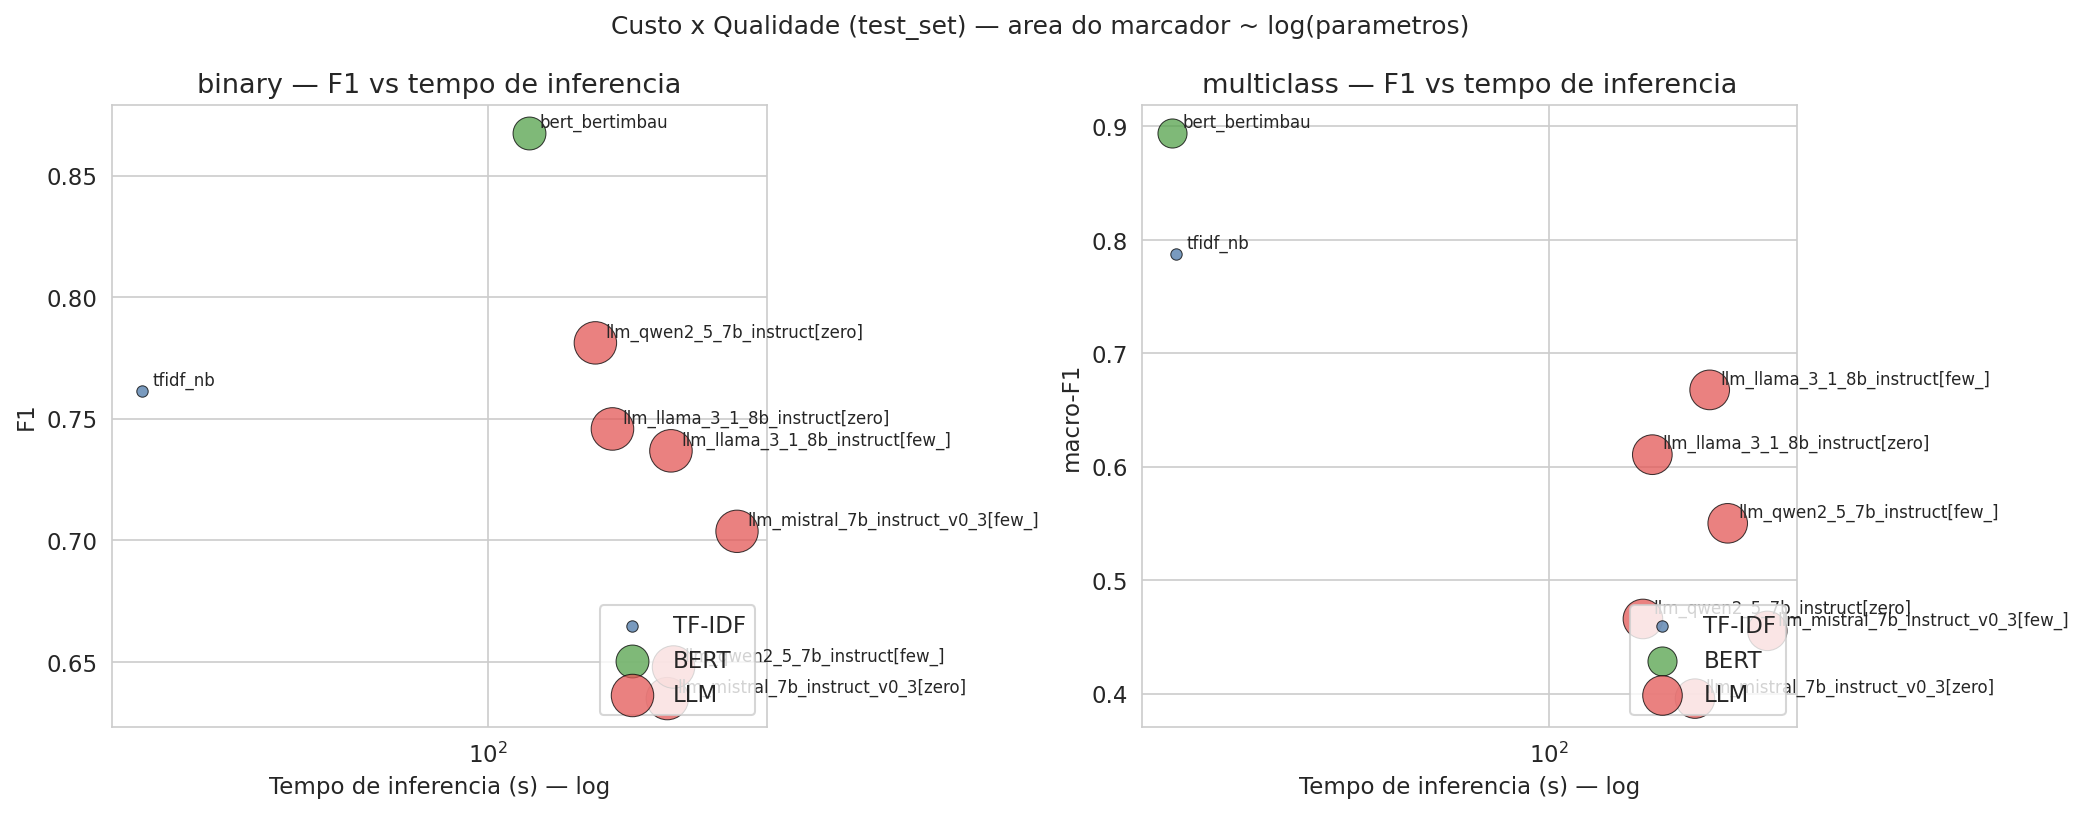

In [9]:
scatter_rows = []
for c in cards:
    if c.get("regime") != "test_set":
        continue
    metrics = c.get("metrics", {}) or {}
    cost = c.get("cost", {}) or {}
    f1 = metrics.get("f1") if c.get("task") == "binary" else metrics.get("macro_f1")
    infer_s = cost.get("inference_seconds_mean", cost.get("inference_seconds"))
    n_params = cost.get("n_parameters")
    if f1 is None or not infer_s or not n_params:
        continue
    label = c["model_id"]
    strat = cost.get("strategy")
    if strat:
        label = f"{label}[{strat[:4]}]"
    scatter_rows.append({
        "label": label,
        "family": family_of(c["model_id"]),
        "task": c.get("task"),
        "f1": f1,
        "infer_s": infer_s,
        "n_params": n_params,
    })
scatter_df = pd.DataFrame(scatter_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
for ax, task in zip(axes, ["binary", "multiclass"]):
    sub = scatter_df[scatter_df["task"] == task]
    if sub.empty:
        ax.set_visible(False)
        continue
    sizes = 30 + 90 * (np.log10(sub["n_params"]) - np.log10(sub["n_params"].min()))
    palette = {"TF-IDF": "#4C78A8", "BERT": "#54A24B", "LLM": "#E45756"}
    for fam, color in palette.items():
        mask = sub["family"] == fam
        ax.scatter(sub.loc[mask, "infer_s"], sub.loc[mask, "f1"], s=sizes[mask], c=color, alpha=0.75, edgecolor="k", linewidth=0.5, label=fam)
    for _, r in sub.iterrows():
        ax.annotate(r["label"], (r["infer_s"], r["f1"]), fontsize=8, xytext=(5, 3), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("Tempo de inferencia (s) — log")
    ax.set_ylabel("F1" if task == "binary" else "macro-F1")
    ax.set_title(f"{task} — F1 vs tempo de inferencia")
    ax.legend(loc="lower right")
fig.suptitle("Custo x Qualidade (test_set) — area do marcador ~ log(parametros)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "cost_quality.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Curvas ROC sobrepostas (binario, test_set)

Apenas modelos com `predictions.csv` contendo `y_score`. As curvas LLM ficam erraticas porque sao avaliadas em ~199 amostras (versus ~16.6k para TF-IDF/BERT).

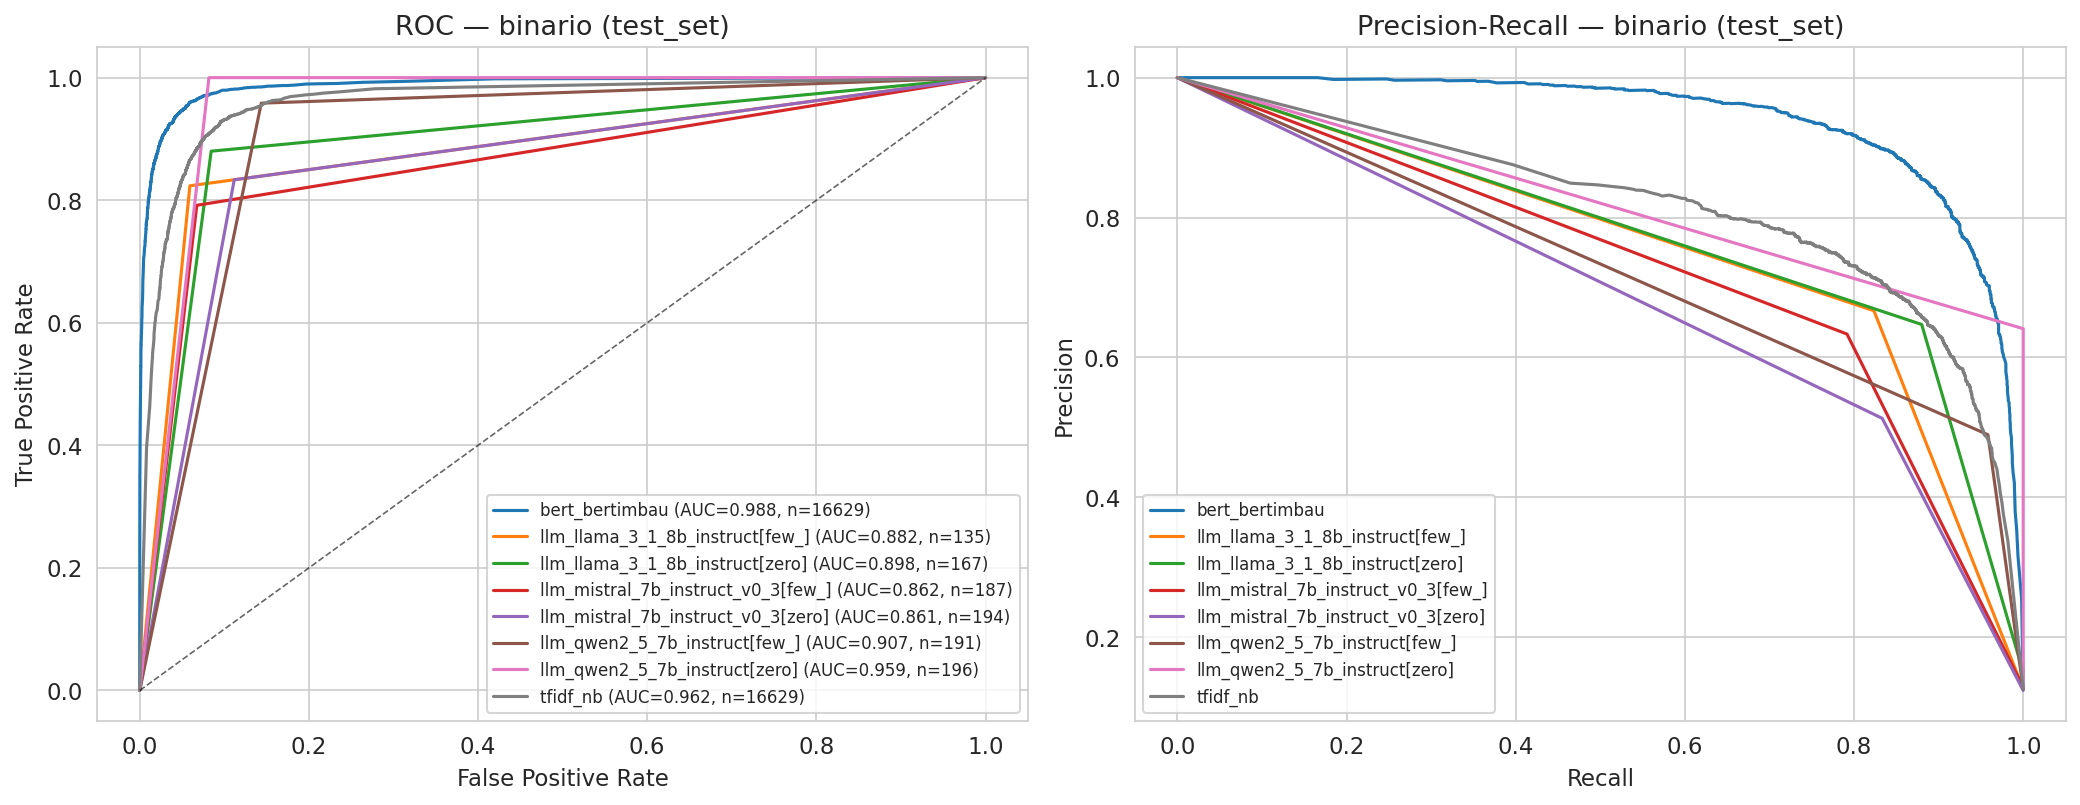

In [10]:
def load_predictions(card: dict) -> pd.DataFrame | None:
    p = card.get("_predictions_local")
    if not p:
        return None
    return pd.read_csv(p)

binary_test_cards = [
    c for c in cards
    if c.get("task") == "binary" and c.get("regime") == "test_set" and c["_predictions_local"]
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5.5))
for c in binary_test_cards:
    df = load_predictions(c)
    if df is None or "y_score" not in df.columns:
        continue
    y_true = df["y_true"].astype(int).to_numpy()
    y_score = df["y_score"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    label = c["model_id"]
    strat = (c.get("cost") or {}).get("strategy")
    if strat:
        label = f"{label}[{strat[:4]}]"
    ax_roc.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f}, n={len(y_true)})", linewidth=1.5)

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ax_pr.plot(rec, prec, label=label, linewidth=1.5)

ax_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.6)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC — binario (test_set)")
ax_roc.legend(fontsize=8, loc="lower right")

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall — binario (test_set)")
ax_pr.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "binary_roc_pr.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Matriz de confusao — binario

Modelo de melhor F1 binario disponivel com `predictions.csv` no test_set.

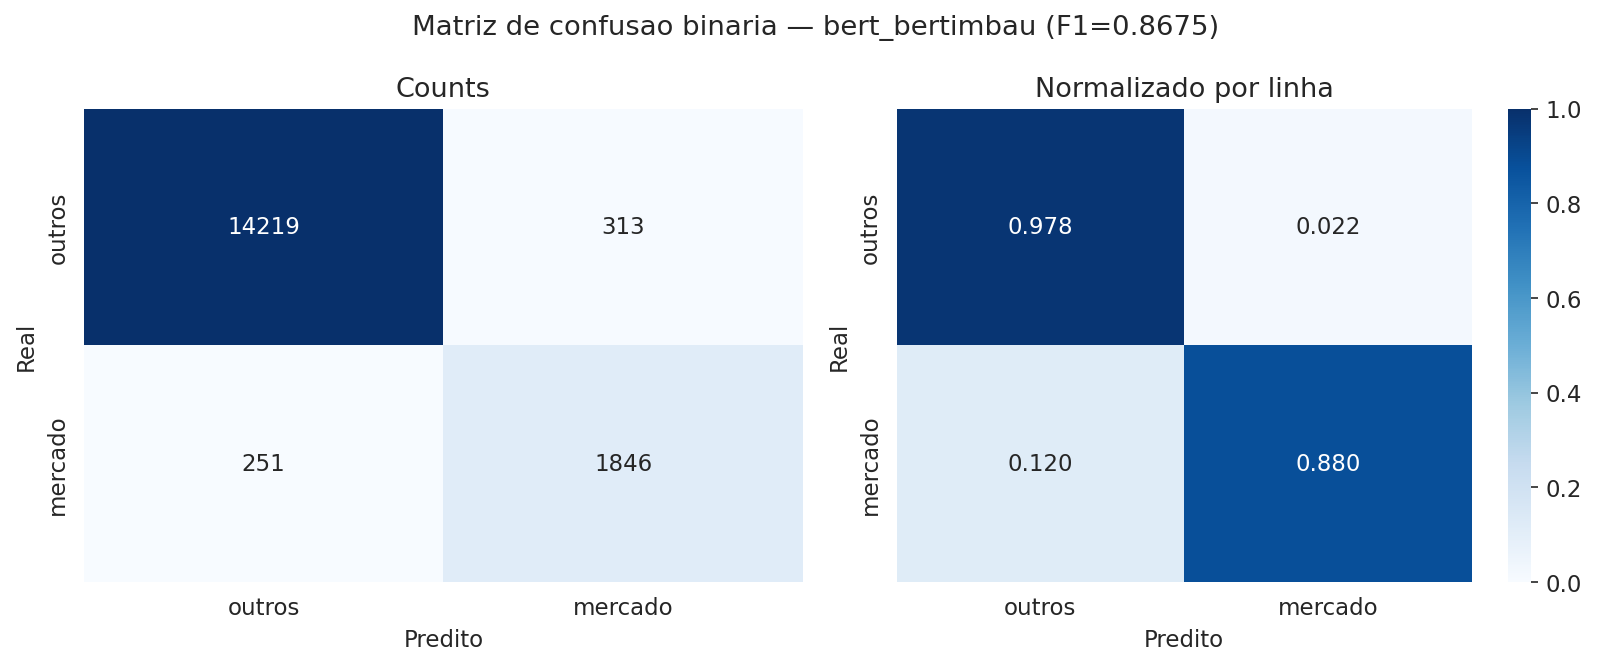

In [11]:
def best_card(cards_list, key):
    valid = [c for c in cards_list if (c.get("metrics") or {}).get(key) is not None]
    return max(valid, key=lambda c: c["metrics"][key]) if valid else None

best_bin = best_card(binary_test_cards, "f1")
if best_bin:
    df = load_predictions(best_bin)
    cm = confusion_matrix(df["y_true"].astype(int), df["y_pred"].astype(int), labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["outros", "mercado"], yticklabels=["outros", "mercado"], cbar=False)
    axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real"); axes[0].set_title("Counts")
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", ax=axes[1],
                xticklabels=["outros", "mercado"], yticklabels=["outros", "mercado"], vmin=0, vmax=1)
    axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real"); axes[1].set_title("Normalizado por linha")
    fig.suptitle(f"Matriz de confusao binaria — {best_bin['model_id']} (F1={best_bin['metrics']['f1']:.4f})")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cm_binary_best.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Nenhum card binario com predictions.csv no test_set.")

## 9. Matriz de confusao — multiclasse

BERTimbau no test_set. A diagonal e visivelmente forte para `esporte`/`ilustrada`/`poder`; `colunas` espalha — efeito esperado da heterogeneidade editorial dessa classe.

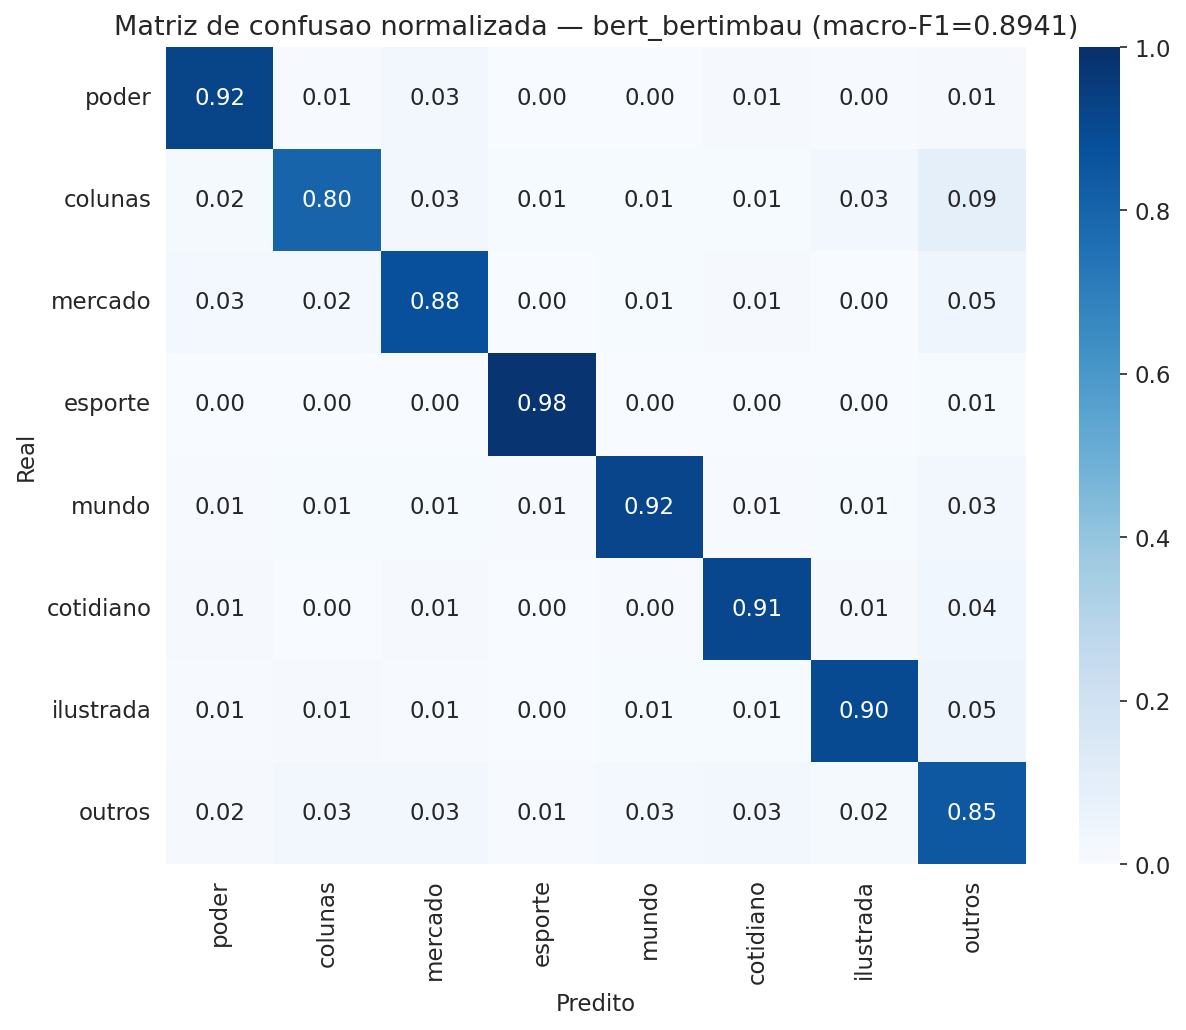

In [12]:
multi_card = next(
    (c for c in cards if c.get("model_id") == "bert_bertimbau"
     and c.get("task") == "multiclass" and c.get("regime") == "test_set"
     and c["_predictions_local"]),
    None,
)
if multi_card:
    df = load_predictions(multi_card)
    labels = MULTICLASS_LABELS
    cm = confusion_matrix(df["y_true"], df["y_pred"], labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(8.5, 7))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusao normalizada — {multi_card['model_id']} (macro-F1={multi_card['metrics']['macro_f1']:.4f})")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cm_multiclass_bert.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("BERTimbau multiclasse test_set sem predictions disponiveis.")

## 10. Distribuicao real x predita das classes (multiclasse, BERTimbau)

Comparacao da prevalencia de cada classe no test_set entre o gold e a predicao do modelo. Desvios indicam vies de chamada do classificador.

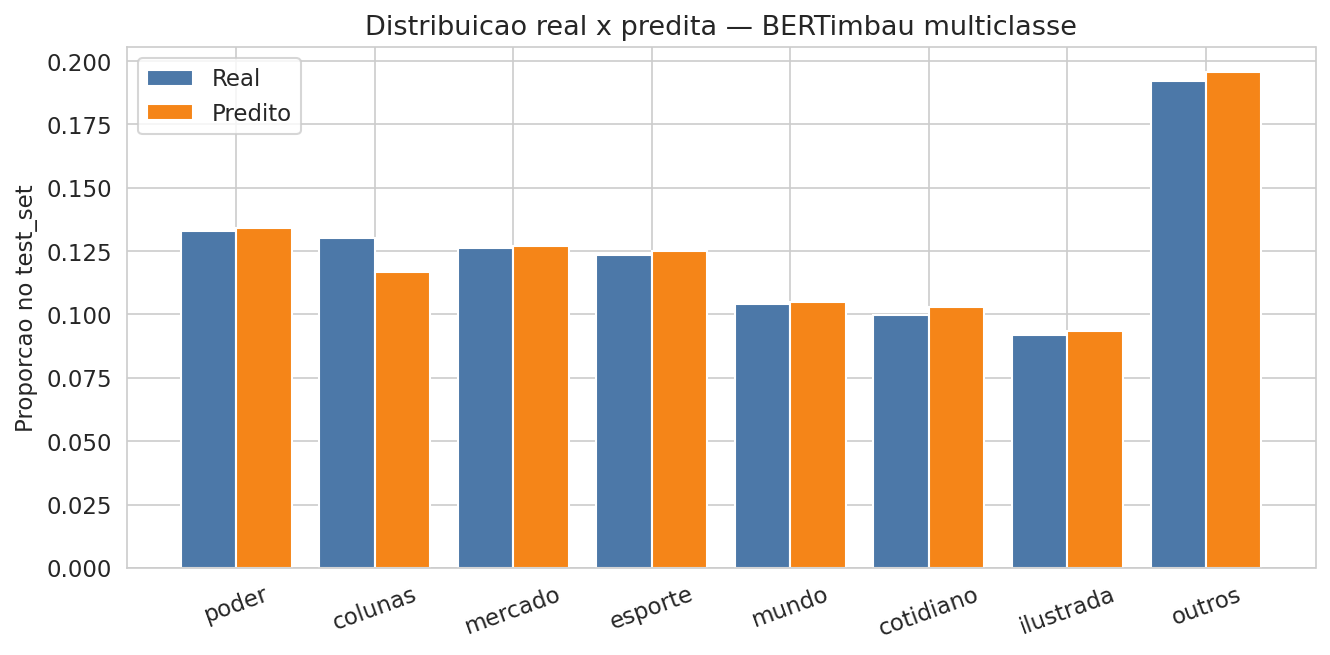

,real,predito
poder,0.1328,0.1339
colunas,0.1300,0.1168
mercado,0.1261,0.1272
esporte,0.1233,0.1251
mundo,0.1041,0.1051
cotidiano,0.0996,0.1028
ilustrada,0.0919,0.0934
outros,0.1921,0.1957


In [13]:
if multi_card:
    df = load_predictions(multi_card)
    real = df["y_true"].value_counts(normalize=True).reindex(MULTICLASS_LABELS).fillna(0)
    pred = df["y_pred"].value_counts(normalize=True).reindex(MULTICLASS_LABELS).fillna(0)
    dist = pd.DataFrame({"real": real, "predito": pred})

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(MULTICLASS_LABELS))
    width = 0.4
    ax.bar(x - width/2, dist["real"], width=width, label="Real", color="#4C78A8")
    ax.bar(x + width/2, dist["predito"], width=width, label="Predito", color="#F58518")
    ax.set_xticks(x, MULTICLASS_LABELS, rotation=20)
    ax.set_ylabel("Proporcao no test_set")
    ax.set_title("Distribuicao real x predita — BERTimbau multiclasse")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "class_dist_real_vs_pred.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(dist.style.format("{:.4f}"))

## 11. Concordancia entre modelos binarios (Cohen's Kappa pareado)

Restrito as predicoes do test_set sobre os mesmos `index`. Modelos com cobertura parcial (LLMs) sao comparados na intersecao com cada par. Kappa proximo de 1 = predicoes redundantes; baixo = potencial para ensemble.

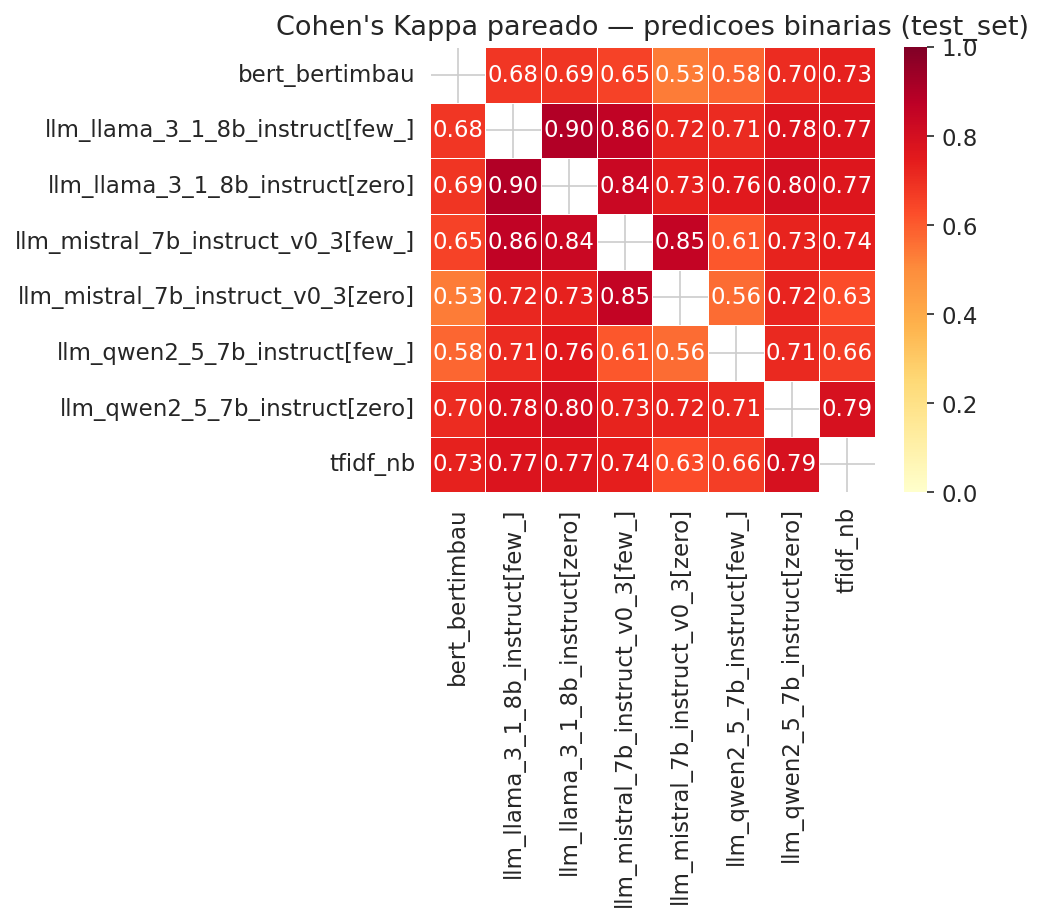

In [14]:
preds_by_model = {}
for c in binary_test_cards:
    df = load_predictions(c)
    if df is None or "y_pred" not in df.columns:
        continue
    label = c["model_id"]
    strat = (c.get("cost") or {}).get("strategy")
    if strat:
        label = f"{label}[{strat[:4]}]"
    preds_by_model[label] = df.set_index("index")["y_pred"].astype(int)

labels = list(preds_by_model.keys())
K = pd.DataFrame(np.nan, index=labels, columns=labels)
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i == j:
            K.loc[a, b] = 1.0
            continue
        common = preds_by_model[a].index.intersection(preds_by_model[b].index)
        if len(common) < 5:
            continue
        K.loc[a, b] = cohen_kappa_score(preds_by_model[a].loc[common], preds_by_model[b].loc[common])

fig, ax = plt.subplots(figsize=(max(7, 0.7 * len(labels)), max(6, 0.6 * len(labels))))
mask = np.eye(len(labels), dtype=bool)
sns.heatmap(K.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", mask=mask, vmin=0, vmax=1, square=True, linewidths=0.4, ax=ax)
ax.set_title("Cohen's Kappa pareado — predicoes binarias (test_set)")
fig.tight_layout()
fig.savefig(FIG_DIR / "binary_kappa.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. LLMs — zero-shot vs few-shot + cobertura

Cobertura mede a fracao de respostas parseadas com sucesso para um label valido. Few-shot tende a aumentar a cobertura (resposta mais formatada) mas nao necessariamente a F1.

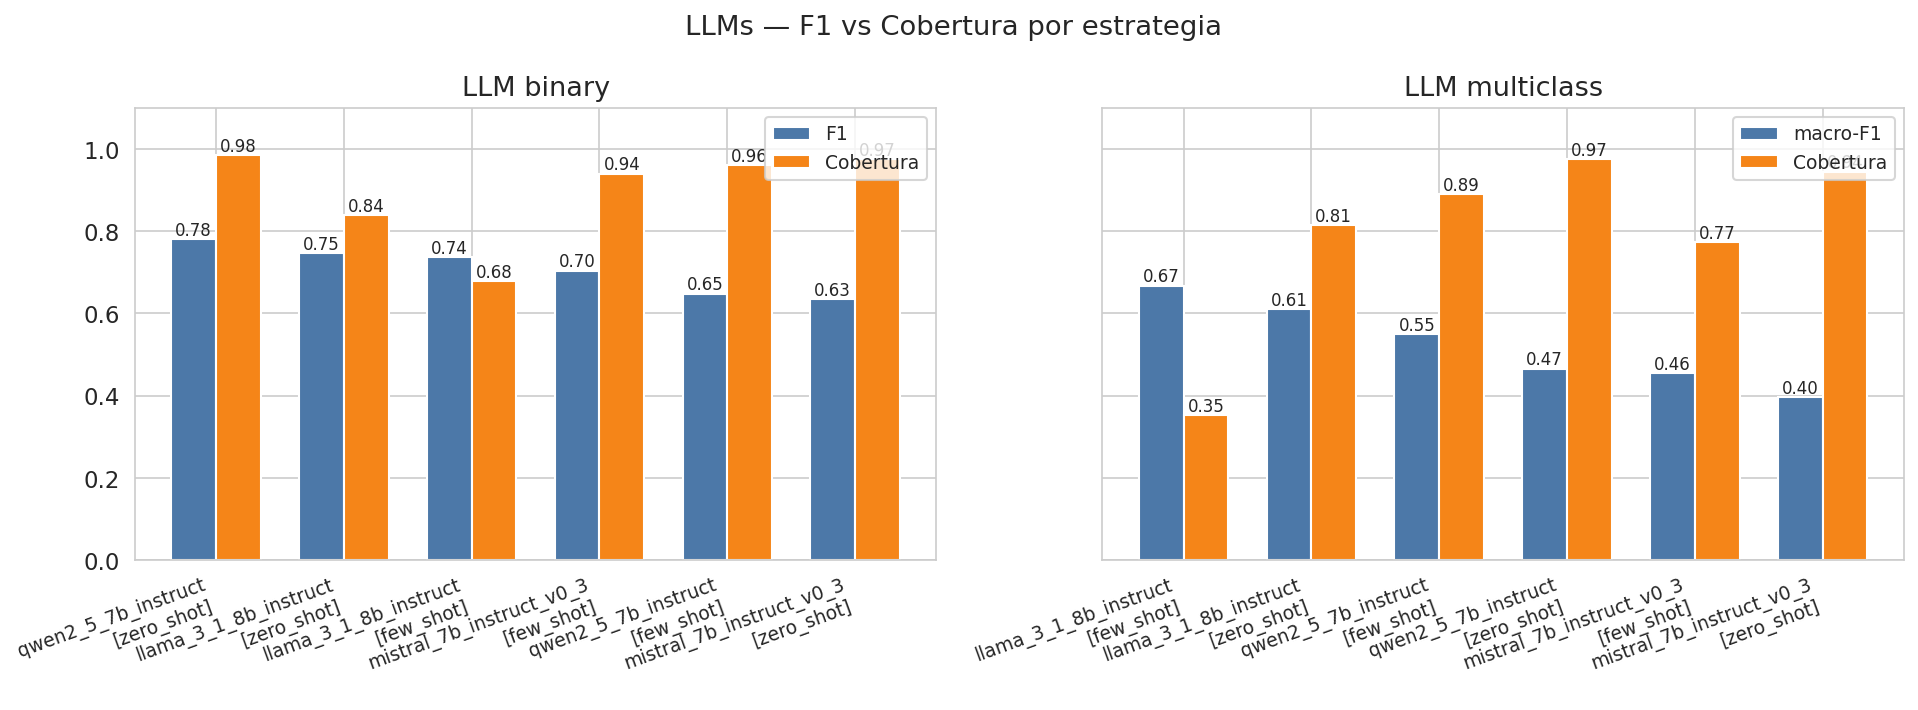

,model,task,strategy,f1,coverage,accuracy
0,llama_3_1_8b_instruct,binary,few_shot,0.7368,0.6784,0.9259
1,llama_3_1_8b_instruct,binary,zero_shot,0.7458,0.8392,0.9102
2,llama_3_1_8b_instruct,multiclass,few_shot,0.6677,0.3518,0.6571
3,llama_3_1_8b_instruct,multiclass,zero_shot,0.6106,0.8141,0.6173
4,mistral_7b_instruct_v0_3,binary,few_shot,0.7037,0.9397,0.9144
5,mistral_7b_instruct_v0_3,binary,zero_shot,0.6349,0.9749,0.8814
6,mistral_7b_instruct_v0_3,multiclass,few_shot,0.4553,0.7739,0.4416
7,mistral_7b_instruct_v0_3,multiclass,zero_shot,0.3956,0.9447,0.3989
8,qwen2_5_7b_instruct,binary,few_shot,0.6479,0.9598,0.8691
9,qwen2_5_7b_instruct,binary,zero_shot,0.7812,0.9849,0.9286


In [15]:
llm_rows = []
for c in cards:
    if not c.get("model_id", "").startswith("llm_"):
        continue
    metrics = c.get("metrics", {}) or {}
    cost = c.get("cost", {}) or {}
    f1 = metrics.get("f1") if c.get("task") == "binary" else metrics.get("macro_f1")
    llm_rows.append({
        "model": c["model_id"].replace("llm_", ""),
        "task": c.get("task"),
        "strategy": cost.get("strategy"),
        "f1": f1,
        "coverage": metrics.get("coverage"),
        "accuracy": metrics.get("accuracy"),
    })
llm_df = pd.DataFrame(llm_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, task in zip(axes, ["binary", "multiclass"]):
    sub = llm_df[llm_df["task"] == task].copy()
    sub = sub.sort_values("f1", ascending=False)
    x = np.arange(len(sub))
    width = 0.35
    bars_f1 = ax.bar(x - width/2, sub["f1"], width=width, color="#4C78A8", label="F1" if task == "binary" else "macro-F1")
    bars_cov = ax.bar(x + width/2, sub["coverage"], width=width, color="#F58518", label="Cobertura")
    for r, v in zip(bars_f1, sub["f1"]):
        ax.text(r.get_x() + r.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    for r, v in zip(bars_cov, sub["coverage"]):
        ax.text(r.get_x() + r.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    labels = [f"{m}\n[{s}]" for m, s in zip(sub["model"], sub["strategy"])]
    ax.set_xticks(x, labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"LLM {task}")
    ax.legend(loc="upper right", fontsize=9)
fig.suptitle("LLMs — F1 vs Cobertura por estrategia")
fig.tight_layout()
fig.savefig(FIG_DIR / "llm_strategy.png", dpi=200, bbox_inches="tight")
plt.show()
llm_df

## 13. Tabela consolidada para o artigo

Agrega todos os `result_card.json` em um CSV unico com schema padronizado: `model_id, task, regime, primary, train_s, inf_s, size_mb, n_parameters, search_s, n_trials`. Linhas ordenadas por (task, regime, primary desc). `primary` e F1 para binario e macro-F1 para multiclasse.

Salvo em `TABLE_DIR/comparison_table.csv` para uso direto na tabela final da dissertacao/artigo.

In [ ]:
TABLE_DIR = FIG_DIR.parent / "tables_eda"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def _primary_metric(card: dict) -> float | None:
    m = card.get("metrics") or {}
    if card.get("task") == "binary":
        return m.get("f1") or m.get("f1_mean")
    return m.get("macro_f1") or m.get("macro_f1_mean")

table_rows = []
for c in cards:
    cost = c.get("cost") or {}
    hp = c.get("hyperparameter_search") or {}
    table_rows.append({
        "model_id": c.get("model_id"),
        "task": c.get("task"),
        "regime": c.get("regime"),
        "primary": _primary_metric(c),
        "train_s": cost.get("train_seconds_mean", cost.get("train_seconds")),
        "inf_s": cost.get("inference_seconds_mean", cost.get("inference_seconds")),
        "size_mb": cost.get("model_size_mb"),
        "n_parameters": cost.get("n_parameters"),
        "search_s": hp.get("search_seconds") if hp else None,
        "n_trials": hp.get("n_trials") if hp else None,
    })

comparison_table = pd.DataFrame(table_rows).sort_values(
    ["task", "regime", "primary"], ascending=[True, True, False]
)
out = TABLE_DIR / "comparison_table.csv"
comparison_table.to_csv(out, index=False)
print(f"Salvo: {out} ({len(comparison_table)} linhas)")
comparison_table

## 14. McNemar pareado com correcao de Bonferroni

Comparacoes pareadas formais entre modelos no `test_set` binario. Duas familias separadas para evitar o anti-padrao de misturar coberturas diferentes (`CLAUDE.md`):

- **Full coverage** (TF-IDF + BERT): todas as ~16.6k amostras, `n_comparisons = K*(K-1)/2`.
- **Com LLMs**: restrita a intersecao dos indices (limitada pelo LLM com menor coverage; tipicamente ~200).

`p_value_adjusted` e o p-valor com Bonferroni para a familia da tabela. `significant_after_correction` e o sinal a reportar no artigo.

In [ ]:
from economy_classifier.evaluation import compute_mcnemar_pairwise

preds_full: dict[str, pd.Series] = {}     # coverage == 1
preds_partial: dict[str, pd.Series] = {}  # qualquer coverage (inclui LLMs)
y_true_lookup: pd.Series | None = None

for c in binary_test_cards:
    df = load_predictions(c)
    if df is None or "y_pred" not in df.columns:
        continue
    df = df.set_index("index")
    label = c["model_id"]
    strat = (c.get("cost") or {}).get("strategy")
    if strat:
        label = f"{label}[{strat[:4]}]"
    cov = (c.get("metrics") or {}).get("coverage", 1.0)
    if cov is None or cov >= 1.0:
        preds_full[label] = df["y_pred"].astype(int)
    preds_partial[label] = df["y_pred"].astype(int)
    if y_true_lookup is None:
        y_true_lookup = df["y_true"].astype(int)

def _run_family(preds: dict[str, pd.Series], name: str, out_name: str) -> pd.DataFrame:
    if len(preds) < 2:
        print(f"Familia '{name}' indisponivel: <2 metodos.")
        return pd.DataFrame()
    common = None
    for s in preds.values():
        common = s.index if common is None else common.intersection(s.index)
    if common is None or len(common) < 30:
        print(f"Familia '{name}' indisponivel: intersecao com n={0 if common is None else len(common)} (< 30).")
        return pd.DataFrame()
    y_t = y_true_lookup.loc[common]
    aligned = {k: v.loc[common] for k, v in preds.items()}
    df = compute_mcnemar_pairwise(y_t, aligned)
    out = TABLE_DIR / out_name
    df.to_csv(out, index=False)
    print(f"Familia '{name}' (n={len(common)}, K={len(preds)}): {out}")
    return df

mcnemar_full = _run_family(preds_full, "full coverage (TF-IDF + BERT)", "mcnemar_full_coverage.csv")
if not mcnemar_full.empty:
    display(mcnemar_full)

mcnemar_all = _run_family(preds_partial, "todos os metodos (incluindo LLMs)", "mcnemar_with_llms.csv")
if not mcnemar_all.empty:
    display(mcnemar_all)

## Notas

- **TF-IDF e BERT** sao avaliados nas ~16.6k amostras do test_set; **LLMs** em ~199 (max_samples=200, com `coverage<1`). Diferencas absolutas em F1 entre grupos nao sao diretamente comparaveis sem reamostragem.
- **`fixed_split` foi descontinuado** como regime principal — preferimos `cv_5fold` para variancia + `test_set` para o numero unico final. As linhas `fixed_split` aparecem aqui apenas para auditoria.
- Figuras sao salvas em `FIG_DIR` (local: `artifacts/figures/eda/`; Colab: `My Drive/economy-classifier/figures/eda/`).